<a href="https://colab.research.google.com/github/Aaditya-Ranjan/CV-Mini-Projects/blob/main/Copy_of_pupil_iris_imp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os


In [ ]:
# Example dataset path (change this to your actual path)
dataset_path = "/content/pupil and iris dataset"




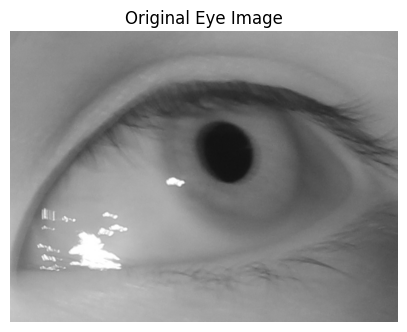

In [ ]:
sample_img_path = os.path.join(dataset_path, os.listdir(dataset_path)[0])
img = cv2.imread("/content/pupil and iris dataset/train/image/0214_1_1_2_32_003.png")
img = cv2.imread("/content/pupil and iris dataset/train/image/0214_2_1_2_31_001.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img_rgb)
plt.title("Original Eye Image")
plt.axis('off')
plt.show()

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_blurred = cv2.medianBlur(gray, 5)

In [ ]:
circles = cv2.HoughCircles(
    gray_blurred,
    cv2.HOUGH_GRADIENT,
    dp=1,                # Inverse ratio of resolution
    minDist=50,          # Minimum distance between detected centers
    param1=100,          # Upper threshold for Canny edge detector
    param2=30,           # Threshold for center detection
    minRadius=20,        # Minimum circle radius
    maxRadius=80         # Maximum circle radius
)

In [ ]:
output = img_rgb.copy()
if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
        # Draw the outer circle (iris or pupil)
        cv2.circle(output, (i[0], i[1]), i[2], (0, 255, 0), 2)
        # Draw the center of the circle
        cv2.circle(output, (i[0], i[1]), 2, (255, 0, 0), 3)

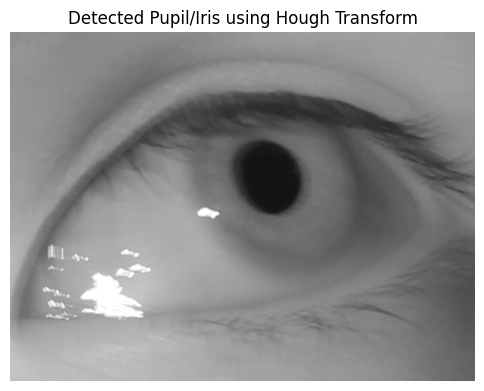

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(output)
plt.title("Detected Pupil/Iris using Hough Transform")
plt.axis('off')
plt.show()

/content/pupil and iris dataset/train/image/0214_1_1_2_53_001.png /content/pupil and iris dataset/train/image/0232_2_1_2_24_003.png


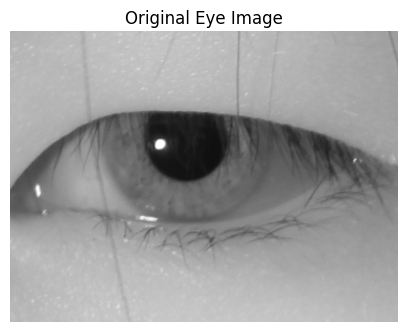

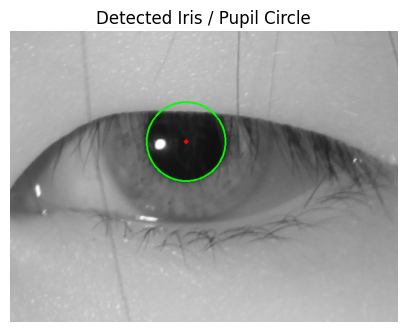

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

dataset_path = "/content/pupil and iris dataset"  # or your actual path

# Step 2: Automatically find an image file in the dataset folder
def find_first_image(path):
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith(('.jpg', '.png', '.jpeg')):
                return os.path.join(root, file)
    return None

# Step 3: Load a sample image
sample_img_path = find_first_image(dataset_path)
print("/content/pupil and iris dataset/train/image/0214_1_1_2_53_001.png", sample_img_path)

if sample_img_path is None:
    raise FileNotFoundError("❌ No image found! Please check your dataset path and structure.")

# Step 4: Read and show image
img = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img_rgb)
plt.title("Original Eye Image")
plt.axis('off')
plt.show()

# Step 5: Preprocess + Detect Circles using Hough Transform
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (9,9), 2)

circles = cv2.HoughCircles(
    blur, cv2.HOUGH_GRADIENT, dp=1, minDist=50,
    param1=100, param2=30, minRadius=20, maxRadius=80
)

output = img_rgb.copy()
if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
        cv2.circle(output, (i[0], i[1]), i[2], (0,255,0), 2)
        cv2.circle(output, (i[0], i[1]), 2, (255,0,0), 3)
else:
    print("⚠️ No circles detected.")

plt.figure(figsize=(5,5))
plt.imshow(output)
plt.title("Detected Iris / Pupil Circle")
plt.axis('off')
plt.show()
